In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score,
    max_error
)

In [32]:
uni_linear = Pipeline([('uni_regressor',LinearRegression())])
uni_linear

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('uni_regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
df = pd.read_csv('datasets/student_scores.csv')
df.head()

,hours_studied,attendance_pct,previous_score,sleep_hours,final_score
0,4.4,69,84,5.7,72.1
1,9.6,64,89,4.6,100.0
2,7.6,91,57,8.6,92.6
3,6.4,68,46,8.4,75.1
4,2.4,64,53,5.3,48.5


# EDA

In [10]:
#info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hours_studied   60 non-null     float64
 1   attendance_pct  60 non-null     int64  
 2   previous_score  60 non-null     int64  
 3   sleep_hours     60 non-null     float64
 4   final_score     60 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 2.5 KB


In [12]:
#Describe
df.describe()

,hours_studied,attendance_pct,previous_score,sleep_hours,final_score
count,60.000000,60.000000,60.000000,60.000000,60.000000
mean,5.211667,74.316667,65.400000,6.521667,73.968333
std,2.754109,14.594510,15.846937,1.439173,15.166103
min,1.200000,50.000000,40.000000,4.000000,48.500000
25%,2.700000,61.750000,53.000000,5.200000,62.950000
50%,5.050000,75.000000,63.000000,6.800000,74.700000
75%,7.450000,88.250000,77.250000,7.600000,85.025000
max,9.700000,99.000000,94.000000,8.900000,100.000000


In [9]:
# Null Values
df.isna().sum()

hours_studied     0
attendance_pct    0
previous_score    0
sleep_hours       0
final_score       0
dtype: int64

In [13]:
#duplicates
df.duplicated().sum()

np.int64(0)

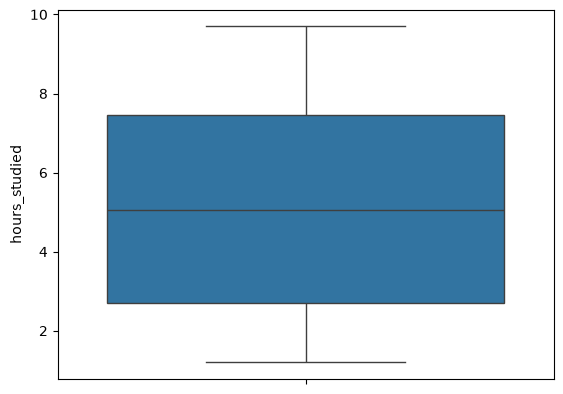

In [14]:
# Outliers
sns.boxplot(df['hours_studied'])
plt.show()

<Axes: xlabel='hours_studied', ylabel='final_score'>

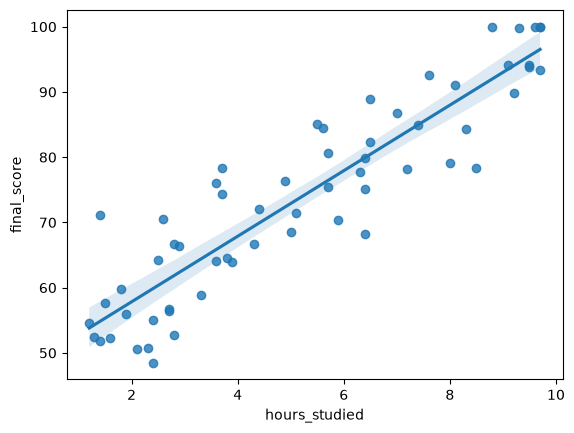

In [15]:
sns.regplot(x=df['hours_studied'],y=df['final_score'])

In [19]:
#Univariate
X=df[['hours_studied']]
y=df[['final_score']]
X_train,X_test,Y_train,Y_Test=train_test_split(X,y,random_state=42,test_size=0.2)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_Test.shape)

(48, 1)
(12, 1)
(48, 1)
(12, 1)


In [33]:
uni_linear.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('uni_regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](1,)",['hours_studied']
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None


In [34]:
score_train_predict = uni_linear.predict(X_train)
score_test_predict = uni_linear.predict(X_test)

In [35]:
Y_train.head()

,final_score
31,64.2
3,75.1
52,94.1
17,80.7
8,68.3


In [36]:
score_train_predict

array([[60.43886053],
       [80.25950738],
       [96.01438051],
       [76.70195538],
       [80.25950738],
       [55.35664339],
       [58.40597367],
       [59.93063882],
       [94.48971537],
       [66.02929939],
       [97.03082394],
       [54.84842168],
       [88.89927652],
       [56.88130853],
       [61.45530396],
       [76.19373367],
       [85.34172452],
       [80.76772909],
       [61.96352567],
       [66.5375211 ],
       [73.6526251 ],
       [94.99793708],
       [97.03082394],
       [55.8648651 ],
       [93.98149366],
       [75.68551195],
       [57.38953025],
       [54.84842168],
       [64.50463424],
       [96.52260223],
       [59.4224171 ],
       [86.35816795],
       [76.70195538],
       [73.14440338],
       [89.91571994],
       [69.58685138],
       [61.45530396],
       [53.83197825],
       [66.02929939],
       [72.63618167],
       [67.55396453],
       [80.76772909],
       [92.45682851],
       [54.34019996],
       [60.94708224],
       [79

In [38]:
r2_score(Y_Test,score_test_predict)

0.7736344852690877

In [39]:
mean_squared_error(Y_Test,score_test_predict)

42.87947626583199

In [40]:
mean_absolute_error(Y_Test,score_test_predict)

5.28502951556944

In [42]:
# Multivariate
feature_columns = ['hours_studied', 'attendance_pct', 'previous_score', 'sleep_hours']
X = df[feature_columns]

In [43]:
X_train,X_test,Y_train,Y_Test=train_test_split(X,y,random_state=42,test_size=0.2)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_Test.shape)

(48, 4)
(12, 4)
(48, 1)
(12, 1)


In [44]:
multi_model = Pipeline([('multi_linear',LinearRegression())])
multi_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('multi_linear', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [45]:
multi_model.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('multi_linear', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['hours_studied','attendance_pct','previous_score','sleep_hours']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None


In [46]:
multi_train_predict = multi_model.predict(X_train)
multi_test_predict = multi_model.predict(X_test)

In [47]:
r2_score(Y_Test,multi_test_predict)

0.9102838358890317

In [48]:
from sklearn.linear_model import LogisticRegression

In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

df = pd.read_csv("datasets/student_pass_fail.csv")
X = df[["hours_studied", "attendance_pct", "previous_score", "sleep_hours"]]
y = df["passed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
]).fit(X_train, y_train)

print("Accuracy:", pipe.score(X_test, y_test))

Task was destroyed but it is pending!
task: <Task pending name='Task-824' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/mukundanramesh/projects/ai_ml_course_bootcamp_practice/aiml_venv/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-825' coro=<Kernel.shell_main() running at /Users/mukundanramesh/projects/ai_ml_course_bootcamp_practice/aiml_venv/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/mukundanramesh/projects/ai_ml_course_bootcamp_practice/aiml_venv/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/mukundanramesh/projects/ai_ml_course_bootcamp_practice/aiml_venv/lib/python3.11/site-packages/pandas/core/series.py:785: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  return self._name
Task was destroyed but it is pending!
task: <Task pending name='Task-825' coro=<Kernel.shell_main() runni

Accuracy: 0.825


In [50]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

test_pred = pipe.predict(X_test)
test_proba = pipe.predict_proba(X_test)[:, 1]  # probability of class 1

print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred))
print("ROC-AUC:", roc_auc_score(y_test, test_proba))

[[14  6]
 [ 1 19]]
              precision    recall  f1-score   support

           0       0.93      0.70      0.80        20
           1       0.76      0.95      0.84        20

    accuracy                           0.82        40
   macro avg       0.85      0.82      0.82        40
weighted avg       0.85      0.82      0.82        40

ROC-AUC: 0.9724999999999999
